# Exploratory Data Analysis — LARS Dataset

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Image Resolution](#image-resolution)
3. [Image-Level Label Distributions](#image-level-label-distributions)
4. [Special Conditions](#special-conditions)
5. [Segmentation Categories](#segmentation-categories)
6. [Sample Visualisation](#sample-visualisation)
7. [Class Imbalance & Biases](#class-imbalance--biases)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import json
import os
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

DATA_ROOT = Path("../Data/lars_v1.0.0_annotations/")
IMAGE_ROOT = Path("../Data/lars_v1.0.0_images/")

SPLITS = ["train", "val", "test"]

## Dataset Overview

The LARS (Large Aquatic River and Sea) dataset is a maritime scene understanding dataset. It provides:
- **Image-level labels**: scene type, lighting, reflections, waves, and special conditions
- **Panoptic segmentation**: pixel-level masks with 11 categories (stuff + things)
- **Splits**: train / val / test (test has image-level labels only, no segmentation masks)


In [3]:
# Load image-level annotations for all splits
annotations = {}
for split in SPLITS:
    with open(DATA_ROOT / split / "image_annotations.json") as f:
        annotations[split] = json.load(f)["annotations"]

for split, anns in annotations.items():
    print(f"{split}: {len(anns)} images")

# Quick look at a single annotation
print("\nExample annotation:")
print(json.dumps(annotations["train"][0], indent=2))

# Load panoptic annotations (train + val only — test has none)
pan_anns = {}
for split in ["train", "val"]:
    with open(DATA_ROOT / split / "panoptic_annotations.json") as f:
        pan_anns[split] = json.load(f)


train: 2605 images
val: 198 images
test: 1203 images

Example annotation:
{
  "id": 1,
  "file_name": "yt010_15_00049.jpg",
  "labels": {
    "scene_type": "river_like",
    "lighting": "day_like",
    "reflections": "moderate",
    "waves": "still",
    "special": {
      "extra_dark": false,
      "extra_bright": false,
      "glitter": false,
      "dirty_lens": false,
      "wakes": false,
      "rain": false,
      "fog": false,
      "plants_debris": false
    }
  }
}


## Image Resolution

In [4]:
for split in ["train", "val"]:
    sizes = set((img["width"], img["height"]) for img in pan_anns[split]["images"])
    print(f"{split}: {sizes}")

train: {(1920, 1440), (1920, 1080), (1280, 702), (1280, 676), (640, 400), (640, 480), (1280, 720), (2208, 1242), (1278, 958), (1280, 1024)}
val: {(1920, 1080), (1920, 1440), (1280, 676), (640, 400), (640, 480), (1280, 720), (2208, 1242), (1280, 1024)}


## Image-Level Label Distributions

Each image is annotated with four categorical labels: `scene_type`, `lighting`, `reflections`, and `waves`.


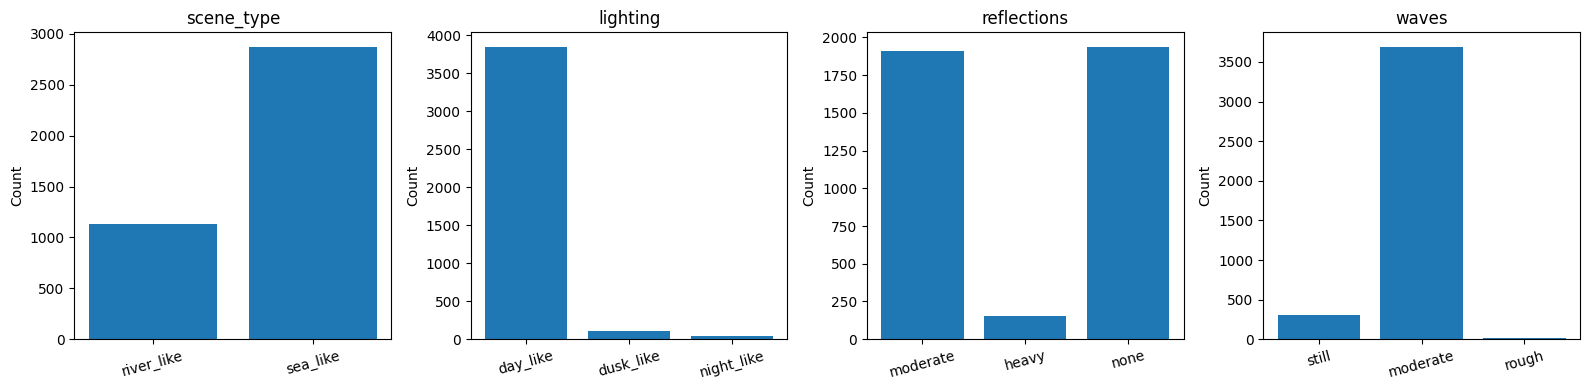

In [5]:
all_anns = [a for split in SPLITS for a in annotations[split]]

label_fields = ["scene_type", "lighting", "reflections", "waves"]

fig, axes = plt.subplots(1, len(label_fields), figsize=(16, 4))

for ax, field in zip(axes, label_fields):
    counts = Counter(a["labels"][field] for a in all_anns if a["labels"][field] is not None)
    ax.bar(counts.keys(), counts.values())
    ax.set_title(field)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Special Conditions

Each image also has a set of boolean flags for challenging visual conditions (e.g. fog, glitter, rain).


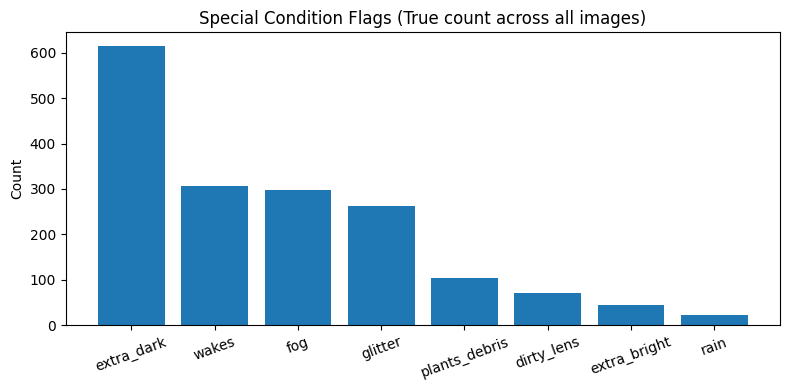

In [6]:
special_counts = Counter()
for a in all_anns:
    for flag, val in a["labels"]["special"].items():
        if val:
            special_counts[flag] += 1

flags, counts = zip(*special_counts.most_common())
plt.figure(figsize=(8, 4))
plt.bar(flags, counts)
plt.title("Special Condition Flags (True count across all images)")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Segmentation Categories

The panoptic annotations contain 11 categories split into **stuff** (background regions: Water, Sky, Static Obstacle) and **things** (countable instances: Boat/ship, Buoy, Swimmer, etc.).


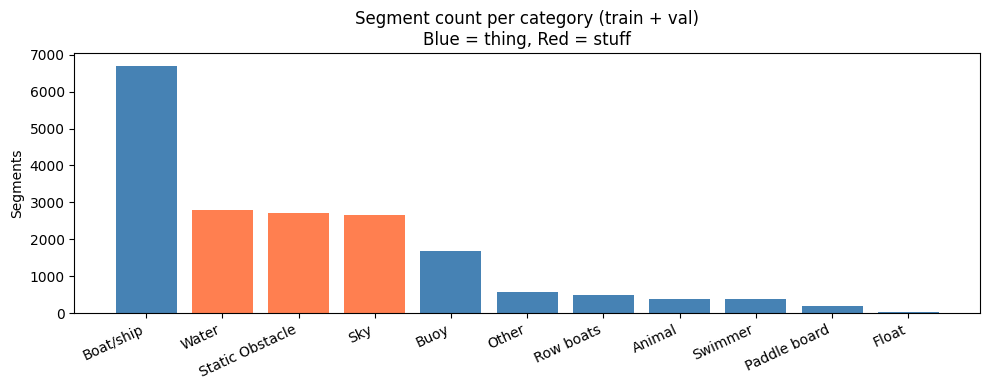

In [7]:
# Load panoptic annotations (train + val only â€” test has none)
pan_anns = {}
for split in ["train", "val"]:
    with open(DATA_ROOT / split / "panoptic_annotations.json") as f:
        pan_anns[split] = json.load(f)

categories = {c["id"]: c for c in pan_anns["train"]["categories"]}

# Count segments per category
seg_counts = Counter()
for split in ["train", "val"]:
    for ann in pan_anns[split]["annotations"]:
        for seg in ann["segments_info"]:
            seg_counts[categories[seg["category_id"]]["name"]] += 1

names, counts = zip(*seg_counts.most_common())
colors = ["steelblue" if categories[[c["id"] for c in categories.values() if c["name"] == n][0]]["isthing"] else "coral"
          for n in names]

plt.figure(figsize=(10, 4))
plt.bar(names, counts, color=colors)
plt.title("Segment count per category (train + val)\nBlue = thing, Red = stuff")
plt.ylabel("Segments")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## Things vs Stuff Content per Image

Each annotated image is classified by whether it contains only **stuff** segments (background: Water, Sky, Static Obstacle), only **thing** segments (countable instances: boats, buoys, etc.), or **both**.

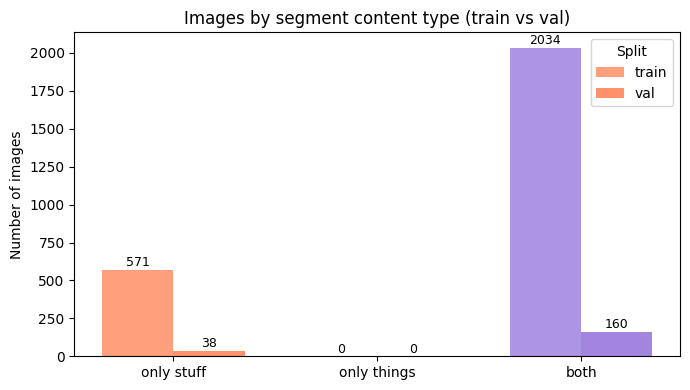

In [8]:
thing_ids = {c["id"] for c in pan_anns["train"]["categories"] if c["isthing"]}

def classify_image(ann):
    has_things = any(seg["category_id"] in thing_ids for seg in ann["segments_info"])
    has_stuff  = any(seg["category_id"] not in thing_ids for seg in ann["segments_info"])
    if has_things and has_stuff:
        return "both"
    elif has_things:
        return "only things"
    else:
        return "only stuff"

split_class_counts = {}
for split in ["train", "val"]:
    counts = Counter(classify_image(ann) for ann in pan_anns[split]["annotations"])
    split_class_counts[split] = counts

categories_order = ["only stuff", "only things", "both"]
x = np.arange(len(categories_order))
width = 0.35
colors_map = {"only stuff": "coral", "only things": "steelblue", "both": "mediumpurple"}

fig, ax = plt.subplots(figsize=(7, 4))
for i, split in enumerate(["train", "val"]):
    vals = [split_class_counts[split].get(c, 0) for c in categories_order]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=split,
                  color=[colors_map[c] for c in categories_order], alpha=0.75 + i * 0.1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(v), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories_order)
ax.set_ylabel("Number of images")
ax.set_title("Images by segment content type (train vs val)")
ax.legend(title="Split")
plt.tight_layout()
plt.show()

## Sample Visualisation

Visualise a few images alongside their panoptic masks and bounding boxes to get a feel for the data.


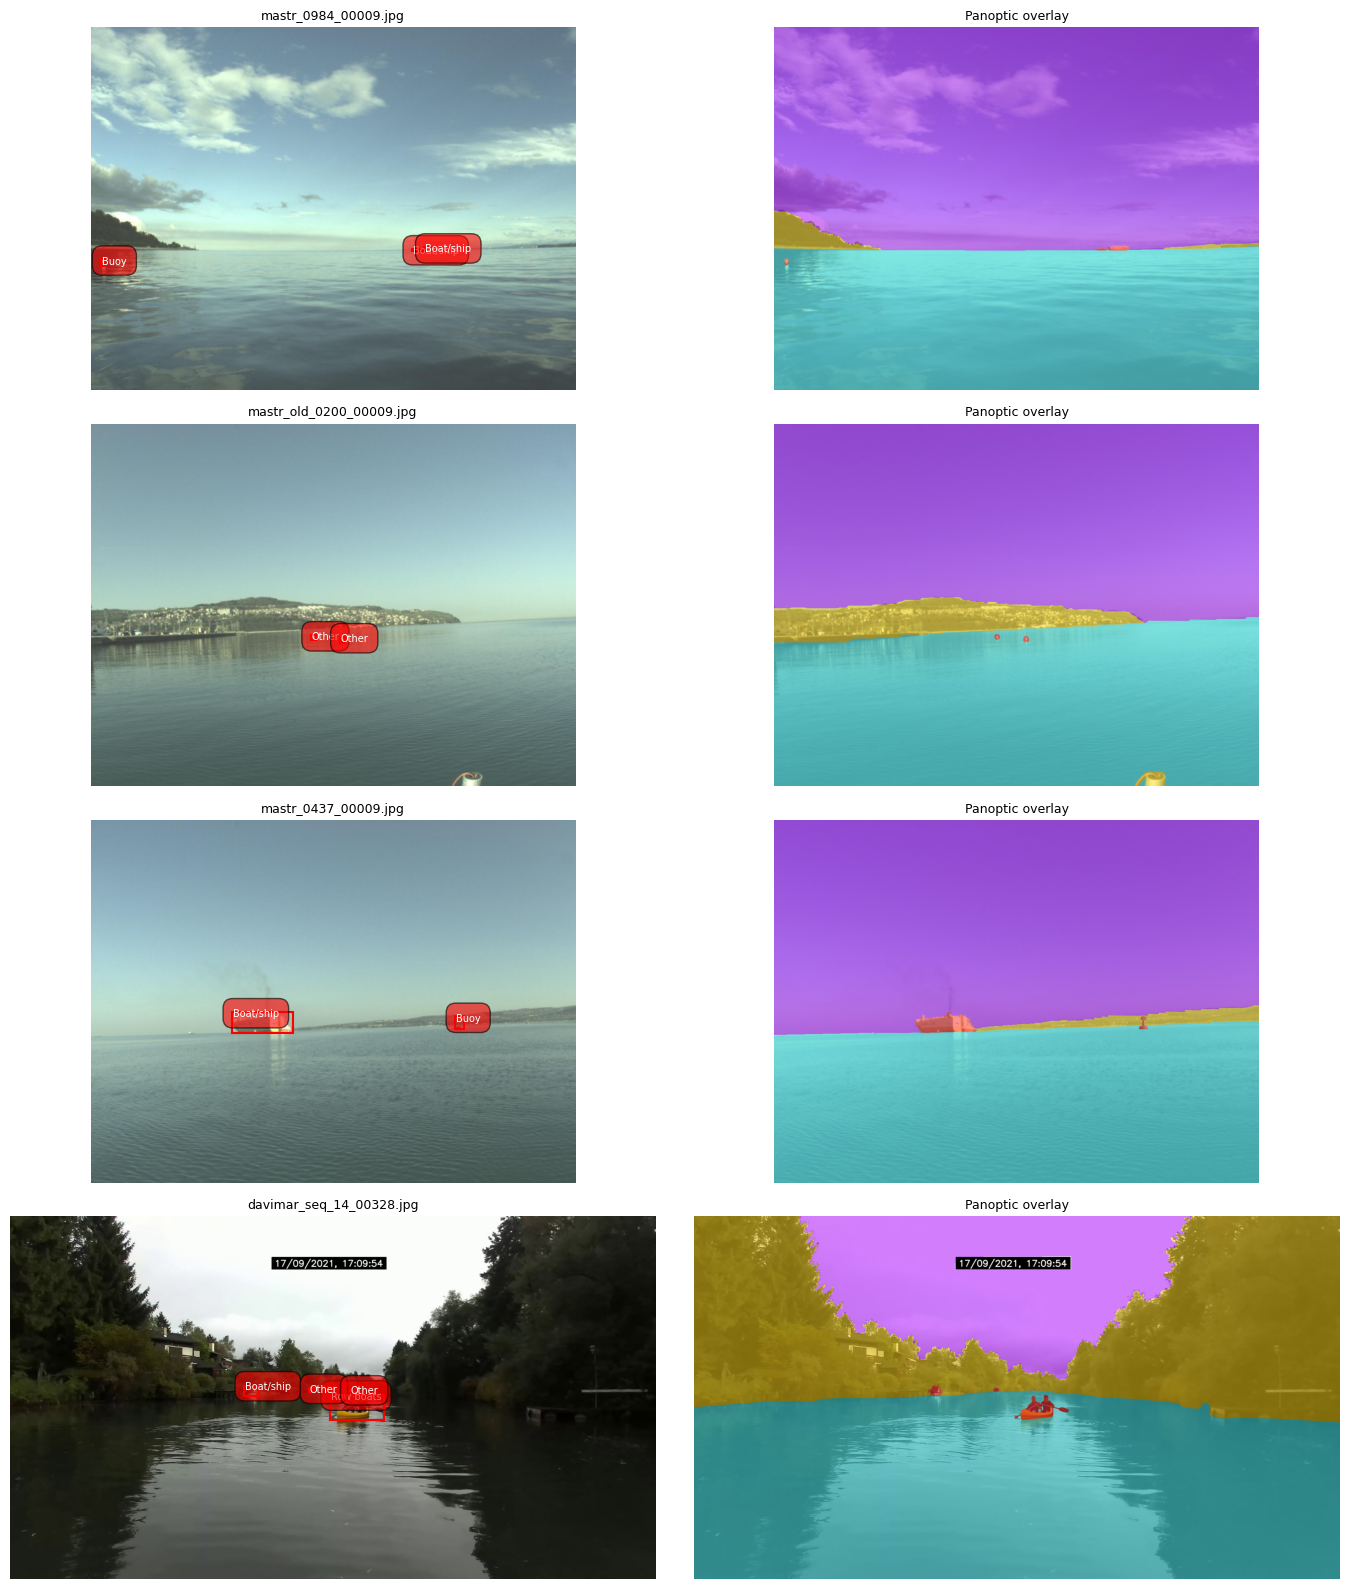

In [9]:
import random

random.seed(4)
N = 4

# Build lookups from panoptic train annotations
cat_colors = {c["id"]: [v / 255 for v in c["color"]] for c in pan_anns["train"]["categories"]}
thing_cat_ids = {c["id"] for c in pan_anns["train"]["categories"] if c["isthing"]}

sample_anns = random.sample(pan_anns["train"]["annotations"], N)

fig, axes = plt.subplots(N, 2, figsize=(14, N * 4))

for i, ann in enumerate(sample_anns):
    mask_name = ann["file_name"]
    img_name  = mask_name.replace(".png", ".jpg")

    img_arr  = np.array(Image.open(IMAGE_ROOT / "train" / "images" / img_name).convert("RGB"))
    mask_arr = np.array(Image.open(DATA_ROOT  / "train" / "panoptic_masks" / mask_name).convert("RGB"))

    # Decode per-pixel segment IDs (COCO panoptic encoding)
    seg_id_map = (mask_arr[:, :, 0].astype(np.int32)
                  + mask_arr[:, :, 1].astype(np.int32) * 256
                  + mask_arr[:, :, 2].astype(np.int32) * 65536)

    # Colour overlay (all categories)
    overlay = img_arr.astype(np.float32) / 255.0
    for seg in ann["segments_info"]:
        px = seg_id_map == seg["id"]
        color = cat_colors.get(seg["category_id"], [1, 0, 0])
        overlay[px] = overlay[px] * 0.5 + np.array(color) * 0.5

    # Left: original image + bounding boxes for things only
    ax_img = axes[i, 0]
    ax_img.imshow(img_arr)
    for seg in ann["segments_info"]:
        if seg["category_id"] not in thing_cat_ids:
            continue
        x, y, w, h = seg["bbox"]
        cat_name = categories[seg["category_id"]]["name"]
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5,
                                  edgecolor="red", facecolor="none")
        ax_img.add_patch(rect)
        ax_img.text(x + 2, y + 12, cat_name, color="white", fontsize=7,
                    bbox=dict(facecolor="red", alpha=0.6, pad=1, boxstyle="round"))
    ax_img.axis("off")
    ax_img.set_title(img_name, fontsize=9)

    # Right: panoptic overlay
    ax_mask = axes[i, 1]
    ax_mask.imshow(overlay)
    ax_mask.axis("off")
    ax_mask.set_title("Panoptic overlay", fontsize=9)

plt.tight_layout()
plt.show()

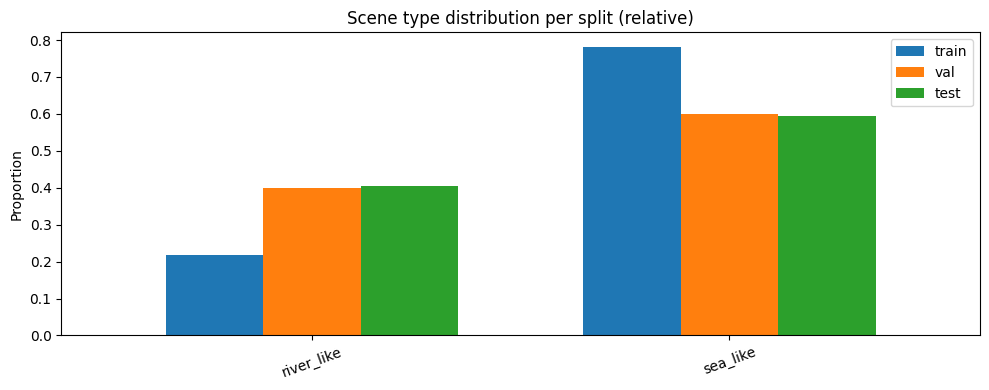

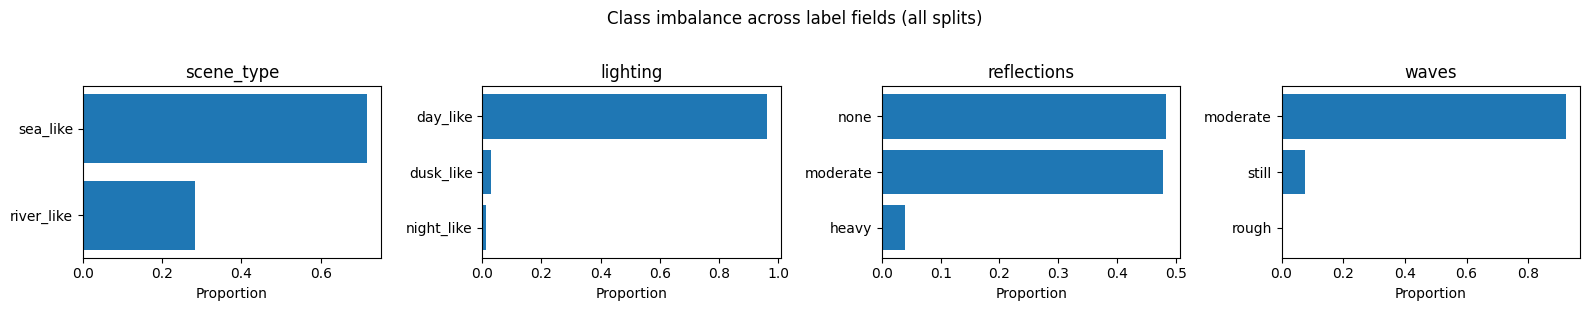

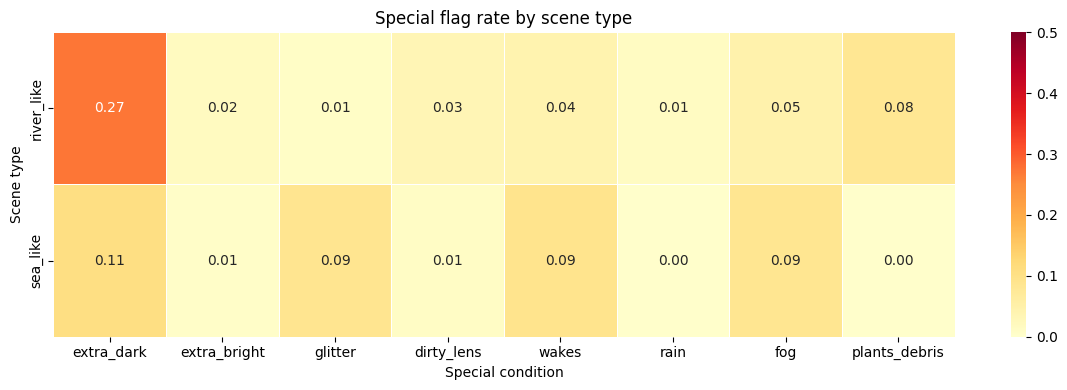

In [10]:
# --- 1. Per-split label distributions for scene_type ---
scene_splits = {}
for split in SPLITS:
    counts = Counter(a["labels"]["scene_type"] for a in annotations[split]
                     if a["labels"]["scene_type"] is not None)
    scene_splits[split] = counts

all_scenes = sorted({k for c in scene_splits.values() for k in c})
split_totals = {split: sum(scene_splits[split].values()) for split in SPLITS}

df_scene = pd.DataFrame(
    {split: [scene_splits[split].get(s, 0) / split_totals[split] for s in all_scenes]
     for split in SPLITS},
    index=all_scenes
)

ax = df_scene.plot(kind="bar", figsize=(10, 4), width=0.7)
ax.set_title("Scene type distribution per split (relative)")
ax.set_ylabel("Proportion")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# --- 2. Dominant vs rare: imbalance ratios across all label fields ---
fig, axes = plt.subplots(1, len(label_fields), figsize=(16, 3))
for ax, field in zip(axes, label_fields):
    counts = Counter(a["labels"][field] for a in all_anns if a["labels"][field] is not None)
    total = sum(counts.values())
    labels_, vals = zip(*counts.most_common())
    ax.barh(labels_, [v / total for v in vals])
    ax.set_title(field)
    ax.set_xlabel("Proportion")
    ax.invert_yaxis()
plt.suptitle("Class imbalance across label fields (all splits)", y=1.02)
plt.tight_layout()
plt.show()

# --- 3. Special flags co-occurrence with scene_type (heatmap) ---
special_flags = list(all_anns[0]["labels"]["special"].keys())
scene_types   = sorted({a["labels"]["scene_type"] for a in all_anns
                         if a["labels"]["scene_type"] is not None})

cooc = pd.DataFrame(index=scene_types, columns=special_flags, dtype=float)
for scene in scene_types:
    scene_anns = [a for a in all_anns if a["labels"]["scene_type"] == scene]
    for flag in special_flags:
        cooc.loc[scene, flag] = sum(a["labels"]["special"][flag] for a in scene_anns) / len(scene_anns)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cooc.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=0.5)
ax.set_title("Special flag rate by scene type")
ax.set_xlabel("Special condition")
ax.set_ylabel("Scene type")
plt.tight_layout()
plt.show()

## Class Imbalance & Biases

TODO
